---  DESCRIPTIVE STATISTICS ---
                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  99

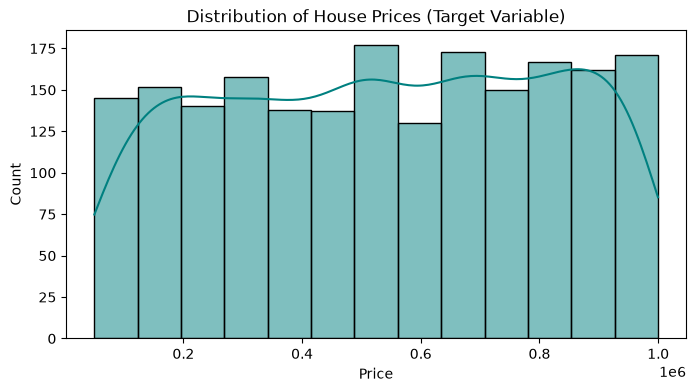

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file
df = pd.read_csv('House Price Prediction Dataset.csv')

print("---  DESCRIPTIVE STATISTICS ---")
print(df.describe())

print("\n--- NULL CHECK ---")
print(df.isnull().sum())

# Plot using capital 'Price' to match your dataset's column name
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='teal')
plt.title('Distribution of House Prices (Target Variable)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

###  Feature Selection Discussion
- **Predictors:** Continuous numerical features like `Area`, `Bedrooms`, `Bathrooms`, and `Stories` are strong physical predictors of market value. 
- **Categorical Factors:** Qualitative variables such as `Mainroad`, `Guestroom`, `Basement`, `Airconditioning`, and `Prefarea` add premium value to properties and must be encoded.
-

C:\Users\91704\AppData\Local\Temp\ipykernel_16668\2352811115.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


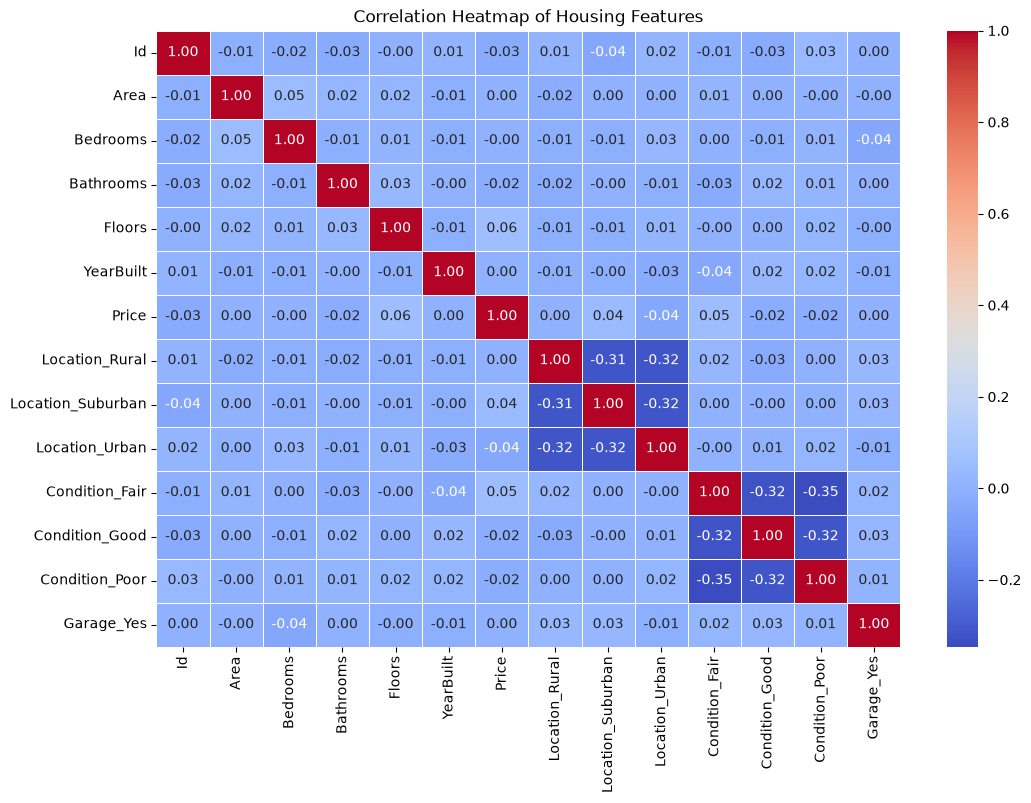

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Identify categorical string columns (like 'yes'/'no')
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding (drop_first=True prevents perfect multicollinearity)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Generate Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Automatically handle text columns (One-Hot Encoding)
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 2. Separate features (X) and target variable (y) using capital 'Price'
X = df_encoded.drop('Price', axis=1)  # Changed 'price' to 'Price'
y = df_encoded['Price']               # Changed 'price' to 'Price'

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f" Model trained successfully!")
print(f"Training shape: {X_train.shape} | Testing shape: {X_test.shape}")

 Model trained successfully!
Training shape: (1600, 13) | Testing shape: (400, 13)


C:\Users\91704\AppData\Local\Temp\ipykernel_16668\2095504423.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [7]:
# Make predictions on test data
y_pred = lr_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("---  LINEAR REGRESSION METRICS ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

---  LINEAR REGRESSION METRICS ---
Mean Squared Error (MSE): 78279764120.86
Root Mean Squared Error (RMSE): 279785.21
R² Score (Variance Explained): -0.0062


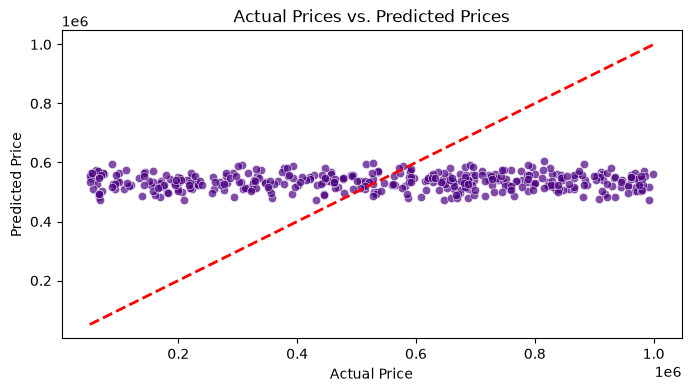

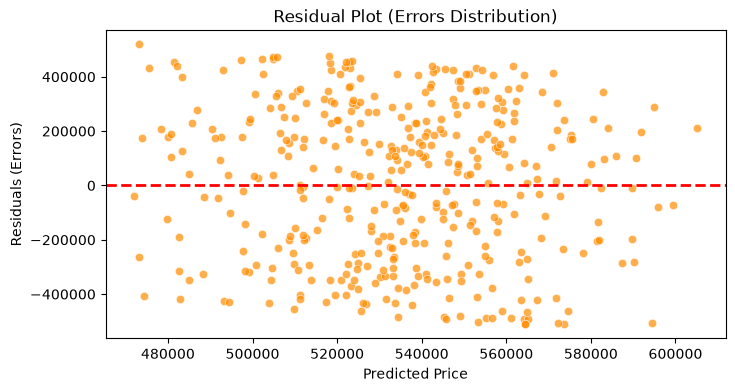

In [8]:
# 1. Scatter Plot: Actual vs. Predicted Prices
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual Prices vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# 2. Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='darkorange')
plt.axhline(y=0, color='red', lw=2, linestyle='--')
plt.title('Residual Plot (Errors Distribution)')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Errors)')
plt.show()

In [9]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient Impact': lr_model.coef_
}).sort_values(by='Coefficient Impact', ascending=False)

print("---  COEFFICIENT ANALYSIS ---")
print(coefficients.to_string(index=False))

---  COEFFICIENT ANALYSIS ---
          Feature  Coefficient Impact
   Condition_Fair        24049.504733
           Floors        23582.408499
Location_Suburban        11110.139855
   Condition_Poor         4389.783506
       Garage_Yes         2218.649484
   Location_Rural         1826.466887
        YearBuilt          116.775334
         Bedrooms           53.249124
             Area           -0.484192
               Id          -12.007473
        Bathrooms        -9835.704344
   Location_Urban       -12601.589640
   Condition_Good       -13048.175894


In [10]:
# Initialize regularized models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=100.0)

# Fit regularized models
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Evaluate scores
print("---  MODEL PERFORMANCE COMPARISON (R² Scores) ---")
print(f"Standard Linear Regression: {r2_score(y_test, lr_model.predict(X_test)):.4f}")
print(f"Ridge Regression:           {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Lasso Regression:           {r2_score(y_test, lasso.predict(X_test)):.4f}")

---  MODEL PERFORMANCE COMPARISON (R² Scores) ---
Standard Linear Regression: -0.0062
Ridge Regression:           -0.0062
Lasso Regression:           -0.0061
